In [6]:
import geopandas as gpd
import pandas as pd
from useful_functions import *
import pickle
import time
import resource_bifiltration as RB
import importlib
import os

import sys
from contextlib import redirect_stdout
from datetime import datetime
import numpy as np
import networkx as nx

import matplotlib as mpl
from shapely.geometry import Point, Polygon
import matplotlib.pyplot as plt

plt.rc('text', usetex=True)
plt.rc('font', family='serif')

plt.rcParams['font.size'] = 18

In [7]:
qs = np.arange(-55, 0, 10)
rs = np.arange(10, 41, 5)

score_col = 'Waste in Place (mil tons)'

thresh_type = 'areaperc'
len_thresh = 0.1

all_params = {
              'rs': rs, 
              'qs': qs, 
              'quality score col': score_col, 
              'threshold type': thresh_type, 
              'threshold': len_thresh}

now = datetime.now()
strdate = now.strftime("%Y-%m-%d")

In [8]:
all_params

{'rs': array([10, 15, 20, 25, 30, 35, 40]),
 'qs': array([-55, -45, -35, -25, -15,  -5]),
 'quality score col': 'Waste in Place (mil tons)',
 'threshold type': 'areaperc',
 'threshold': 0.1}

In [9]:
path_to_files = 'geographic_data/'
results_folder = 'Results_Landfills_Nuisance'

fileextra = f'_{thresh_type}_{str(len_thresh).replace('.', 'p')}'

blocks = gpd.read_file(path_to_files +'tl_2020_17_tract/tl_2020_17_tract.shp')
blocks = blocks.drop(index=[3235,2385])
blocks = blocks.reset_index(drop=True)
blocks.to_crs('EPSG:26916')

ratings = pd.read_csv(path_to_files + "Landfill_Data_Cleaned.csv")
ratings = ratings.fillna(0)

# flip so we can do sublevelset still
ratings['Waste in Place (tons) ORIGINAL'] = (ratings['Waste in Place (tons)'])/1000000 #+ max(ratings['Waste in Place (tons)'])

# divide by 1 mil so numbers arent so insane
ratings['Waste in Place (mil tons)'] = -1*ratings['Waste in Place (tons) ORIGINAL']

In [22]:
ratings.head()

,Unnamed: 0,Landfill ID,Landfill Name,State,Physical Address,City,County,Zip Code,Latitude,Longitude,Year Landfill Opened,Landfill Closure Year,Current Landfill Status,Waste in Place (tons),Waste in Place (tons) ORIGINAL,Waste in Place (mil tons)
0,0,1859,31st Street Landfill,IL,11700 West 31st Street,Westchester,Cook,60154.0,41.838940,-87.914970,1960.0,1982.0,Closed,9582454.0,9.582454,-9.582454
1,1,500,ADS/McLean County LF #2,IL,2105 W. Oakland Avenue,Bloomington,McLean,61704.0,40.472866,-89.037718,1990.0,2018.0,Closed,2626797.0,2.626797,-2.626797
2,2,503,Alton Municipal Landfill,IL,4550 N. Alby Street,Godfrey,Madison,62035.0,38.928000,-90.179000,1976.0,1992.0,Closed,660557.0,0.660557,-0.660557
3,3,1858,American Grading Company,IL,5100 Lawndale Avenue,McCook,Cook,60525.0,41.799478,-87.823965,1954.0,1995.0,Closed,7000000.0,7.000000,-7.000000
4,4,521,Beecher Landfill,IL,1055 W. Goodenow Road,Beecher,Will,60401.0,41.391500,-87.638800,1972.0,1996.0,Closed,4613270.0,4.613270,-4.613270


In [10]:
G = adjacency_graph(blocks, calc_area=True)
D = np.load('geographic_data/landfills_distances_geodesic_NEW.npy')

rb = RB.ResourceBifiltration(scores = ratings[score_col].values, D = D, G = G)

In [11]:
########## Make sure folders exist ##########
os.makedirs(f'{results_folder}/{strdate}', exist_ok=True)
results_folder = results_folder + f"/{strdate}/"

In [12]:
with open(f'{results_folder}/LANDFILLS_nuisance_STDOUT{fileextra}.txt', 'w') as f:
    with redirect_stdout(f):
        print("Running code to generate TCC.")
        print(f"r values: {rs}")
        print(f"q values: {qs}")
        print("Code started at:", now.strftime("%Y-%m-%d_%H:%M:%S"))
        TCC = RB.TrackedComponentCollection(rb, rs, qs, len_thresh = len_thresh, blocks = blocks, thresh_type=thresh_type)

with open(f'{results_folder}/LANDFILLS_nuisance_TCC{fileextra}.pkl', 'wb') as file:
    pickle.dump(TCC, file)

with open(f'{results_folder}/LANDFILLS_nuisance_{strdate}_PARAMS{fileextra}.pkl', 'wb') as file:
    pickle.dump(all_params, file)

In [13]:
print("Starting postprocess merging...")
########## Postprocess Merging ##########
G = construct_graph(TCC)

# Components that need to be merged
big_Cs = [C for C in nx.connected_components(G) if len(C) > 1]

# Components that don't need to be merged but save for later
small_cs = [C for C in nx.connected_components(G) if len(C) == 1]
small_TCs = [next(iter(i)) for i in small_cs]

# merge all components that are in the connected component 
merged_TCs = []

# Loop through the components C of the graph G. Each of these is a set of tracked components we want to merge
for i, C in enumerate(big_Cs):
    # print(f"Set {i}")
    # Initialize merged_TC to the first TC in C
    # print("Initializing with TC #0")
    C = list(C)
    merged_TC = C[0]
    
    # Merge in the others one by one
    for j, TC in enumerate(C[1:]):
        # print(f"Merging in TC #{j + 1}")
        merged_TC = TCC.get_merged_tracked_comp(merged_TC, TC)
    merged_TCs.append(merged_TC)
    # print("------------------------------------\n")


all_TCs = merged_TCs+small_TCs

Starting postprocess merging...


In [14]:
with open(f'{results_folder}/LANDFILLS_nuisance_post_initial_merge{fileextra}.pkl', 'wb') as file:
    pickle.dump(all_TCs, file)

# Final Merging

In [15]:
mergethreshold = 0.9
fileextra += f'_{str(mergethreshold).replace('.', 'p')}' 

# Post process merging
overlapamt = np.zeros([len(all_TCs),len(all_TCs)])

for i, TC1 in enumerate(all_TCs):
        
        all_sets1 = list(TC1.C_reps.values())
        TC1_max_rep = set.union(*all_sets1)
            
        for j, TC2 in enumerate(all_TCs):
            if i<j:
                all_sets2 = list(TC2.C_reps.values())
                TC2_max_rep = set.union(*all_sets2)

                amt_1_in_2 = len(TC2_max_rep.intersection(TC1_max_rep)) / len(TC2_max_rep)
                amt_2_in_1 = len(TC1_max_rep.intersection(TC2_max_rep)) / len(TC1_max_rep)

                overlapamt[i,j] = max(amt_1_in_2, amt_2_in_1)
                overlapamt[j,i] = overlapamt[i,j]
            elif i == j:
                 overlapamt[i,j] = 1

G = nx.Graph()
G.add_nodes_from(range(len(all_TCs)))

# Only look at upper triangle to avoid duplicate edges
rows, cols = np.where(np.triu(overlapamt, k=1) > mergethreshold)

edges = [(r, c, overlapamt[r, c]) for r, c in zip(rows, cols)]
G.add_weighted_edges_from(edges)

singletons = [node for node, degree in G.degree() if degree == 0]
G.remove_nodes_from(singletons)

nomerge_needed_dicts = []
for tc in [all_TCs[i] for i in singletons]:
        all_sets = list(tc.C_reps.values())
        max_rep = set.union(*all_sets)
        lifetime = len(tc.C_reps.keys())
        plotting_dict = {'maxrep': max_rep, 'lifetime': lifetime}

        nomerge_needed_dicts.append(plotting_dict)


# Get connected components as subgraphs
components = [G.subgraph(c) for c in nx.connected_components(G)]

# # Classify components into three lists
# non_trees = [c for c in components if not nx.is_tree(c)]
# pairs     = [c for c in components if nx.is_tree(c) and c.number_of_nodes() == 2]
# trees     = [c for c in components if nx.is_tree(c) and c.number_of_nodes() != 2]

print(f"Number of components: {len(components)}")
# print(f"Number of non-trees:  {len(non_trees)}")
# print(f"Number of pairs:      {len(pairs)}")
# print(f"Number of trees:      {len(trees)}")

Number of components: 4


In [16]:
colors=['C0','C1','C2','C3','C4','C5','C6','C7','C8','C9']
colors = colors+colors+colors+colors+colors+colors+colors+colors+colors
for i, c in enumerate(components):
    tccomp = [all_TCs[i] for i in c.nodes]
    fig, ax = plt.subplots(1,3, figsize=(10,3))
    # new_tc = merge_dicts_v2(*[TC.C_reps for TC in tccomp])
    nodecolors = []
    for j,tc in enumerate(tccomp):
        all_sets = list(tc.C_reps.values())
        max_rep = set.union(*all_sets)

        currentmaxrep = blocks[blocks.index.isin(max_rep)]
        union_mr = currentmaxrep.union_all()
        mr = gpd.GeoSeries(union_mr, crs=blocks.crs)

        mr.plot(ax=ax[1], edgecolor=colors[j], facecolor='none', label=j)
        nodecolors.append(colors[j])

    new_tc = merge_dicts_v2(*[TC.C_reps for TC in tccomp])
    all_sets = list(new_tc.values())
    max_rep = set.union(*all_sets)
    currentmaxrep = blocks[blocks.index.isin(max_rep)]
    union_mr = currentmaxrep.union_all()
    mr = gpd.GeoSeries(union_mr, crs=blocks.crs)
    mr.plot(ax=ax[0], color='pink', label=j)

    ax[0].axis('off')
    ax[1].axis('off')

    nx.draw(c,ax=ax[2], node_color=nodecolors, with_labels=False, node_size=70)

    plt.savefig(f'{results_folder}/TEMP/Component{i}.png', bbox_inches = 'tight', dpi = 300)
    plt.close()

In [17]:
merged_dicts = []
for c in components:

    tccomp = [all_TCs[i] for i in c.nodes]
    new_tc = merge_dicts_v2(*[TC.C_reps for TC in tccomp])
    all_sets = list(new_tc.values())
    max_rep = set.union(*all_sets)
    lifetime = len(new_tc.keys())
    plotting_dict = {'maxrep': max_rep, 'lifetime': lifetime}
            
    merged_dicts.append(plotting_dict)

all_dicts = nomerge_needed_dicts + merged_dicts

with open(f'{results_folder}/LANDFILLS_nuisance_final_step_{fileextra}.pkl', 'wb') as file:
    pickle.dump(all_dicts, file)

## Plots

In [18]:
TCC = all_dicts

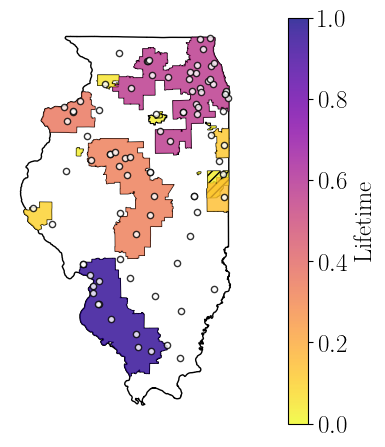

In [37]:
########## All Maximal Components, colored by range ##########
cmap = mpl.colormaps['plasma_r']
norm = mpl.colors.Normalize(vmin=0, vmax=1)  # scale from 0 to 1

plottingalph = 0.8

geometry = [Point(xy) for xy in zip(ratings['Longitude'], ratings['Latitude'])]

geo_df = gpd.GeoDataFrame(ratings, #specify our data
                          geometry=geometry, crs='EPSG:4326')

geo_df = geo_df.to_crs('EPSG:4326')

union_geom = blocks.union_all()
boundary = gpd.GeoSeries(union_geom.boundary)

fig, ax = plt.subplots(figsize=(10,5))
boundary.plot(ax=ax, color='black', linewidth=1)

sorted_comps = sorted(TCC, key=lambda x: x["lifetime"], reverse=False)

geo_df.plot(ax=ax, color='k', marker='o', markersize=20, zorder=1000, alpha=0.8, facecolors='white') #, edgecolors='black')

# sorted_TCs = [x for (x,_,_) in sorted(zip(all_TCs,normalized_values,color_mapvals), key=lambda pair: pair[1])]
# sorted_color_mapvals = [z for (_,_,z) in sorted(zip(all_TCs,normalized_values,color_mapvals), key=lambda pair: pair[1])]
# print(sorted_TCs)

for i, TC in enumerate(sorted_comps): #enumerate(all_TCs):
    maxrep = TC['maxrep']
    lifetime = TC['lifetime']/ (len(rs) * len(qs))

    currentmaxrep = blocks[blocks.index.isin(maxrep)]
    union_mr = currentmaxrep.union_all()
    mr = gpd.GeoSeries(union_mr, crs=blocks.crs)

    if i == 3:
        mr.plot(ax=ax, color=cmap(lifetime), alpha=plottingalph, zorder=(i+1), hatch='////')
    else:
        mr.plot(ax=ax, color=cmap(lifetime), alpha=plottingalph, zorder=(i+1))

    mr.boundary.plot(ax=ax, color='k', linewidth=0.75) #, linestyle='dashed')

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # required for older versions of matplotlib
cbar = fig.colorbar(sm, ax=ax, alpha=plottingalph) 
cbar.set_label('Lifetime')

plt.tight_layout()
plt.axis('off')

plt.savefig(f'{results_folder}/LANDFILLS_nuisance_Maxrep_ALL_lifetime{fileextra}.png', bbox_inches = 'tight', dpi = 300)

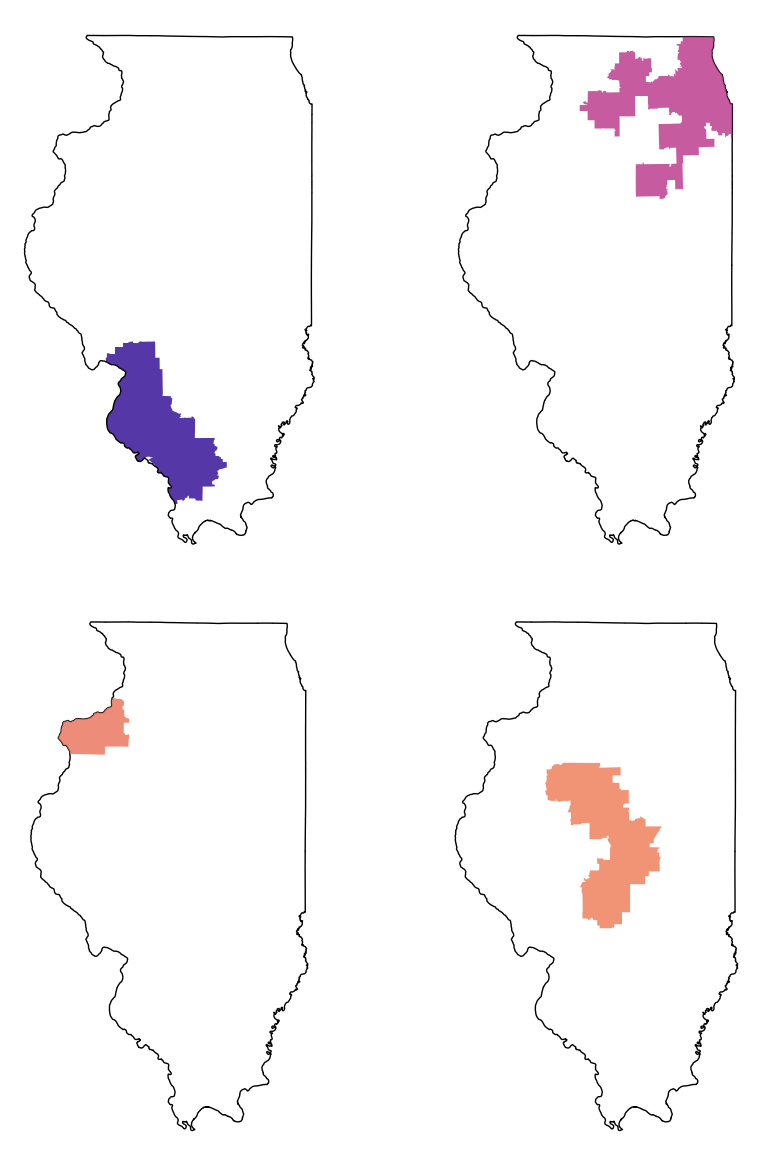

In [ ]:
########## Top 10 components in individual figures ##########
plt.rcParams['font.size'] = 18

cmap = mpl.colormaps['plasma_r']
norm = mpl.colors.Normalize(vmin=0, vmax=1)  # scale from 0 to 1

plottingalph = 0.8

union_geom = blocks.union_all()
boundary = gpd.GeoSeries(union_geom.boundary)

sorted_comps = sorted(TCC, key=lambda x: x["lifetime"], reverse=True)

fig, ax = plt.subplots(2,2,figsize=(10,12))
# boundary.plot(ax=ax, color='black', linewidth=1)

# axes = [ax]*10
axes = ax.flatten()

for i, TC in enumerate(sorted_comps[:4]): #enumerate(all_TCs):
    maxrep = TC['maxrep']
    lifetime = TC['lifetime']/ (len(rs) * len(qs))

    boundary.plot(ax=axes[i], color='black', linewidth=1)

    currentmaxrep = blocks[blocks.index.isin(maxrep)]
    union_mr = currentmaxrep.union_all()
    mr = gpd.GeoSeries(union_mr, crs=blocks.crs)

    mr.plot(ax=axes[i], color=cmap(lifetime), alpha=plottingalph, zorder=(i+1))

    axes[i].axis('off')

plt.tight_layout()

plt.savefig(f'{results_folder}/LANDFILLS_nuisance_Maxrep_SepFigs_lifetime.png', bbox_inches = 'tight', dpi = 300)